Anzahl gefundener Runs: 207


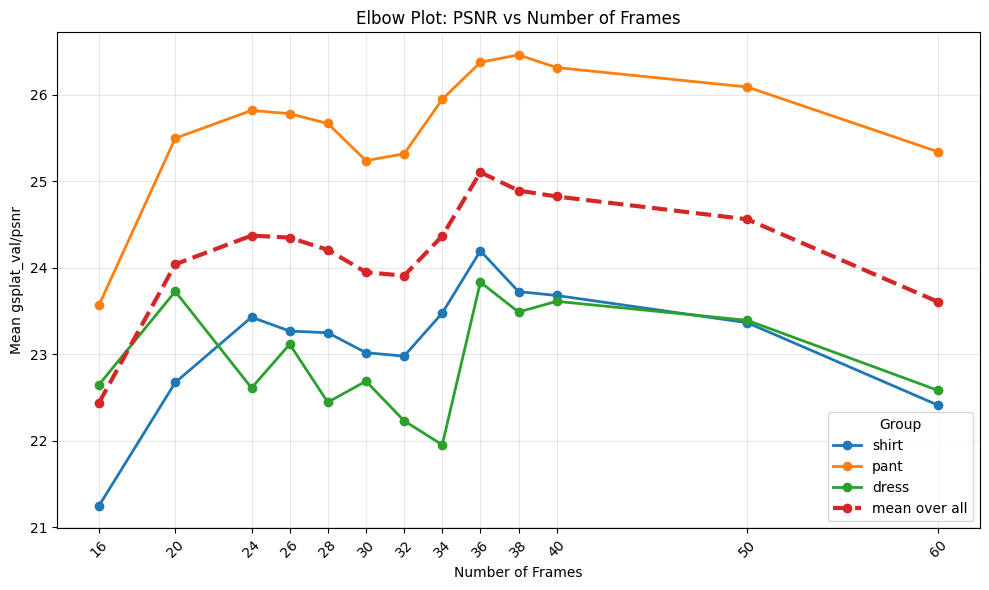

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import wandb

api = wandb.Api()

entity = "vton_pipeline"
project = "vton_pipeline_frames_detailed"

valid_frames = [16, 20, 24, 26, 28, 30, 32, 34, 36, 38, 40, 50, 60]
valid_clothes = ["shirt", "pant", "dress"]

runs = api.runs(f"{entity}/{project}")

pattern = re.compile(
    r"^exp\d+_([a-zA-Z0-9\-]+)_(shirt|pant|dress)_nf(\d+)$",
    re.IGNORECASE
)

rows = []

for r in runs:
    name = (r.name or "").strip()
    match = pattern.match(name)
    if not match:
        continue

    person, cloth, nf = match.groups()
    cloth = cloth.lower()
    nf = int(nf)

    if cloth not in valid_clothes or nf not in valid_frames:
        continue

    psnr = r.summary.get("gsplat_val/psnr", None)
    if psnr is None:
        continue

    rows.append({
        "run_name": name,
        "person": person,
        "cloth": cloth,
        "frames": nf,
        "psnr": float(psnr),
    })

df = pd.DataFrame(rows)

print("Anzahl gefundener Runs:", len(df))

# Mittelwert pro Kleidungsstück und Framezahl
df_mean = (
    df.groupby(["cloth", "frames"], as_index=False)["psnr"]
      .mean()
      .sort_values(["cloth", "frames"])
)

# Globaler Mittelwert über ALLES pro Framezahl
df_global_mean = (
    df.groupby("frames", as_index=False)["psnr"]
      .mean()
      .sort_values("frames")
)

plt.figure(figsize=(10, 6))

# Linien pro Kleidungsstück
for cloth in valid_clothes:
    sub = df_mean[df_mean["cloth"] == cloth].sort_values("frames")
    plt.plot(
        sub["frames"],
        sub["psnr"],
        marker="o",
        linewidth=2,
        label=cloth
    )

# Zusätzliche Mean-Linie über alles
plt.plot(
    df_global_mean["frames"],
    df_global_mean["psnr"],
    marker="o",
    linewidth=3,
    linestyle="--",
    label="mean over all"
)

plt.xlabel("Number of Frames")
plt.ylabel("Mean PSNR")
plt.title("Elbow Plot: PSNR vs Number of Frames")
plt.xticks(valid_frames, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Group")
plt.tight_layout()
plt.show()